## Optimization: Backpropagation

## Overview
In this exercise we will use backpropagation to train a multi-layer perceptron (with a single hidden layer).  We will experiment with different patterns and see how quickly or slowly the weights converge.  We will see the impact and interplay of different parameters such as learning rate, number of iterations, and number of data points.

Shape of Full X Matrix is: (500, 3)
Shape of Y is: (500,)


C:\Users\LEI\AppData\Local\Temp\ipykernel_20260\3548831007.py:20: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "ro" (-> color='r'). The keyword argument will take precedence.
  ax.plot(x_matrix_full[y==1, 0], x_matrix_full[y==1, 1], 'ro', label='Class 1', color='darkslateblue')
C:\Users\LEI\AppData\Local\Temp\ipykernel_20260\3548831007.py:21: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "bx" (-> color='b'). The keyword argument will take precedence.
  ax.plot(x_matrix_full[y==0, 0], x_matrix_full[y==0, 1], 'bx', label='Class 0', color='chocolate')


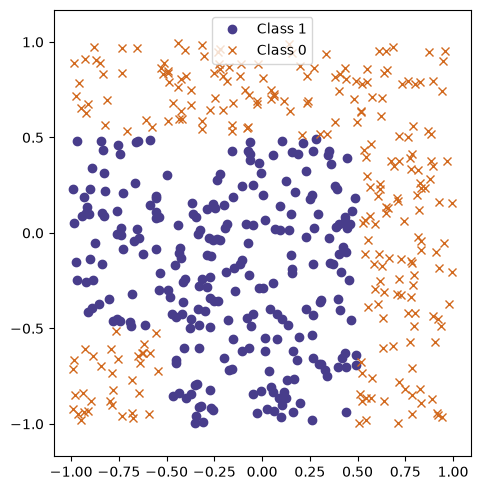

In [1]:
import matplotlib.pyplot as plt
import numpy as np

observations = 500
x_matrix = np.random.uniform(-1, 1, size= (observations, 2))
x_matrix_bias = np.ones((observations, 1))
x_matrix_full = np.concatenate((x_matrix, x_matrix_bias), axis=1)

circle_pattern = (np.sqrt(x_matrix_full[:,0]**2 + x_matrix_full[:,1]**2)<.75).astype(int)
diamond_pattern = ((np.abs(x_matrix_full[:,0]) + np.abs(x_matrix_full[:,1]))<1).astype(int)
centered_square = ((np.maximum(np.abs(x_matrix_full[:,0]), np.abs(x_matrix_full[:,1])))<.5).astype(int)

y = (((np.maximum((x_matrix_full[:,0]), (x_matrix_full[:,1])))<.5) & ((np.maximum((x_matrix_full[:,0]), (x_matrix_full[:,1])))>-.5)).astype(int)
thin_ra = (((np.maximum((x_matrix_full[:,0]), (x_matrix_full[:,1])))<.5) & ((np.maximum((x_matrix_full[:,0]), (x_matrix_full[:,1])))>0)).astype(int)

print('Shape of Full X Matrix is: {}'.format(x_matrix_full.shape))
print('Shape of Y is: {}'.format(y.shape))

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(x_matrix_full[y==1, 0], x_matrix_full[y==1, 1], 'ro', label='Class 1', color='darkslateblue')
ax.plot(x_matrix_full[y==0, 0], x_matrix_full[y==0, 1], 'bx', label='Class 0', color='chocolate')
ax.legend(loc='best')
ax.axis('equal')
plt.tight_layout()

## Helper Functions

In [2]:
# sigmoid activation function
def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))

def forward_pass(W1, W2):

    global x_mat, y, num_

    # compute the predictions
    z_2 = np.dot(x_mat, W1)
    a_2 = sigmoid(z_2)
    z_3 = np.dot(a_2, W2)
    y_hat = sigmoid(z_3).reshape((len(x_mat), ))

    # compute the gradient
    J_z_3_grad = -y + y_hat
    J_W_2_grad = np.dot(J_z_3_grad, a_2)
    a_2_z_2_grad = sigmoid(z_2) * (1 - sigmoid(z_2))
    J_W_1_grad = (np.dot((J_z_3_grad).reshape(-1, 1), W2.reshape(-1, 1).T) * a_2_z_2_grad).T.dot(x_mat).T
    gradient = (J_W_1_grad, J_W_2_grad)

    return y_hat, gradient

def plot_loss_accuracy(loss_vals, accuracies):
    fig = plt.figure(figsize=(16, 8))
    fig.suptitle('Log Loss and Accuracy over iterations')
    
    ax = fig.add_subplot(1, 2, 1)
    ax.plot(loss_vals)
    ax.grid(True)
    ax.set(xlabel='iterations', title='Log Loss')
    
    ax = fig.add_subplot(1, 2, 2)
    ax.plot(accuracies)
    ax.grid(True)
    ax.set(xlabel='iterations', title='Accuracy')

# loss function
def loss_fn(y_true, y_pred, epsilon=1e-16):
    y_pred = np.maximum(y_pred, epsilon)
    y_pred = np.minimum(y_pred, (1 - epsilon))
    return -(np.sum(y_true * np.log(y_pred)) + np.sum((1 - y_true) * np.log(1 - y_pred))) / len(y_true)

Iteration: 0 | Log Loss: 0.7913 | Accuracy: 0.498


C:\Users\LEI\AppData\Local\Temp\ipykernel_20260\1743180074.py:25: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig = plt.figure(figsize=(16, 8))


Iteration: 200 | Log Loss: 0.5364 | Accuracy: 0.756
Iteration: 400 | Log Loss: 0.5122 | Accuracy: 0.758
Iteration: 600 | Log Loss: 0.4785 | Accuracy: 0.792
Iteration: 800 | Log Loss: 0.4263 | Accuracy: 0.858
Iteration: 1000 | Log Loss: 0.3732 | Accuracy: 0.9
Iteration: 1200 | Log Loss: 0.3217 | Accuracy: 0.9
Iteration: 1400 | Log Loss: 0.2785 | Accuracy: 0.896
Iteration: 1600 | Log Loss: 0.2505 | Accuracy: 0.894
Iteration: 1800 | Log Loss: 0.2299 | Accuracy: 0.916
Iteration: 2000 | Log Loss: 0.2130 | Accuracy: 0.932
Iteration: 2200 | Log Loss: 0.1983 | Accuracy: 0.936
Iteration: 2400 | Log Loss: 0.1849 | Accuracy: 0.946
Iteration: 2600 | Log Loss: 0.1722 | Accuracy: 0.956
Iteration: 2800 | Log Loss: 0.1601 | Accuracy: 0.956
Iteration: 3000 | Log Loss: 0.1489 | Accuracy: 0.96
Iteration: 3200 | Log Loss: 0.1393 | Accuracy: 0.962
Iteration: 3400 | Log Loss: 0.1311 | Accuracy: 0.964
Iteration: 3600 | Log Loss: 0.1241 | Accuracy: 0.966
Iteration: 3800 | Log Loss: 0.1180 | Accuracy: 0.968
It

MemoryError: bad allocation

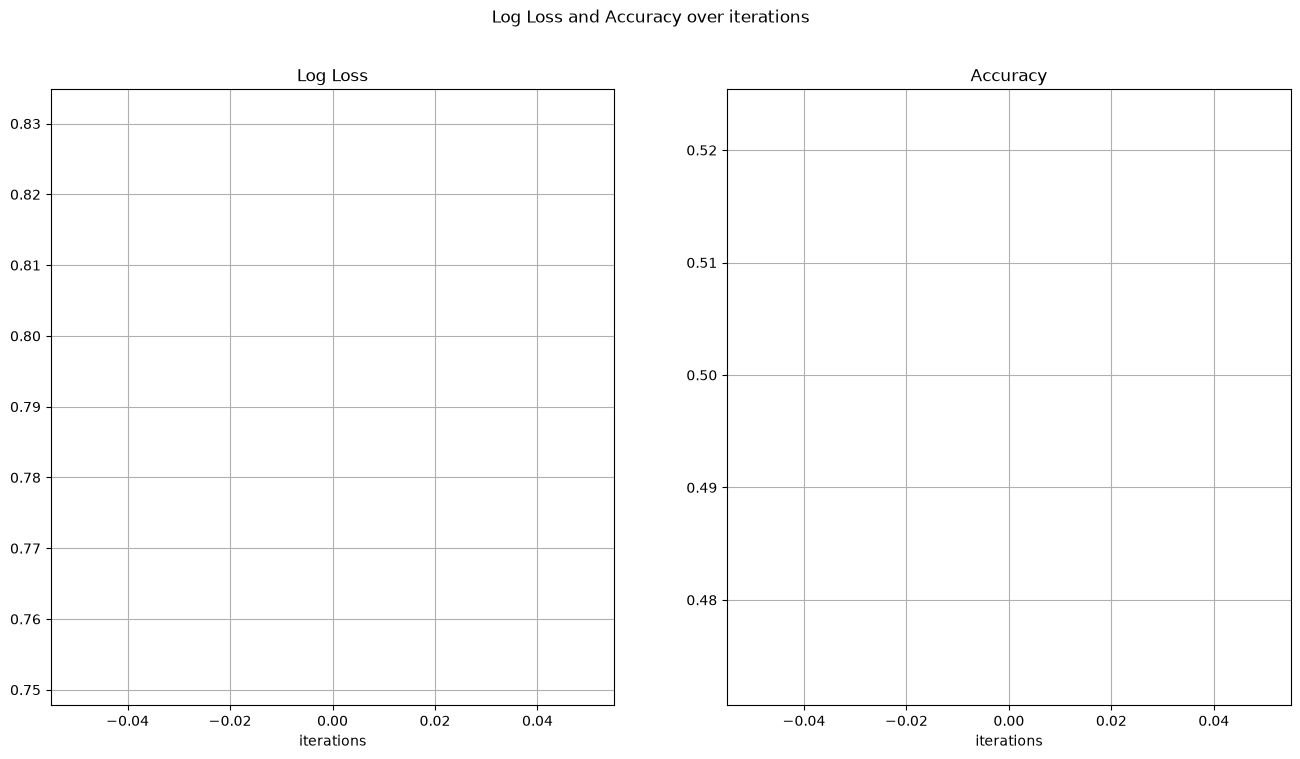

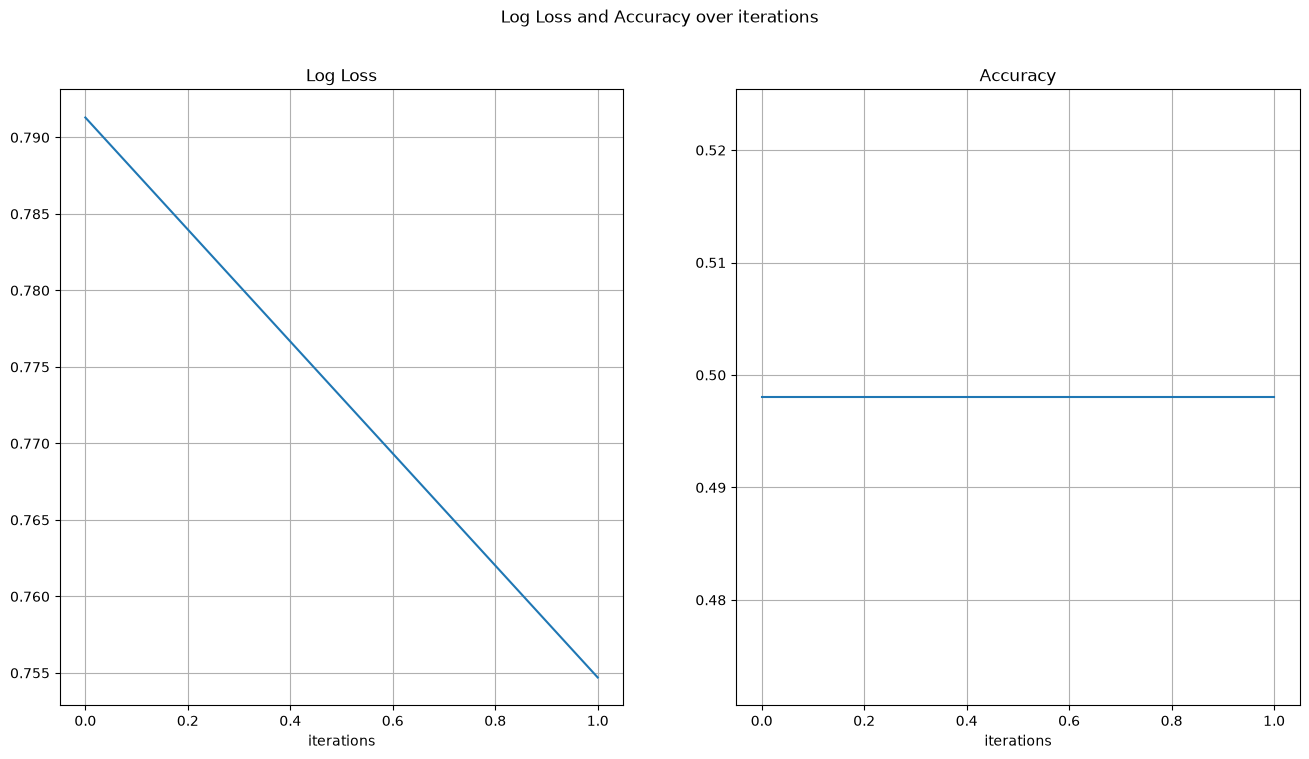

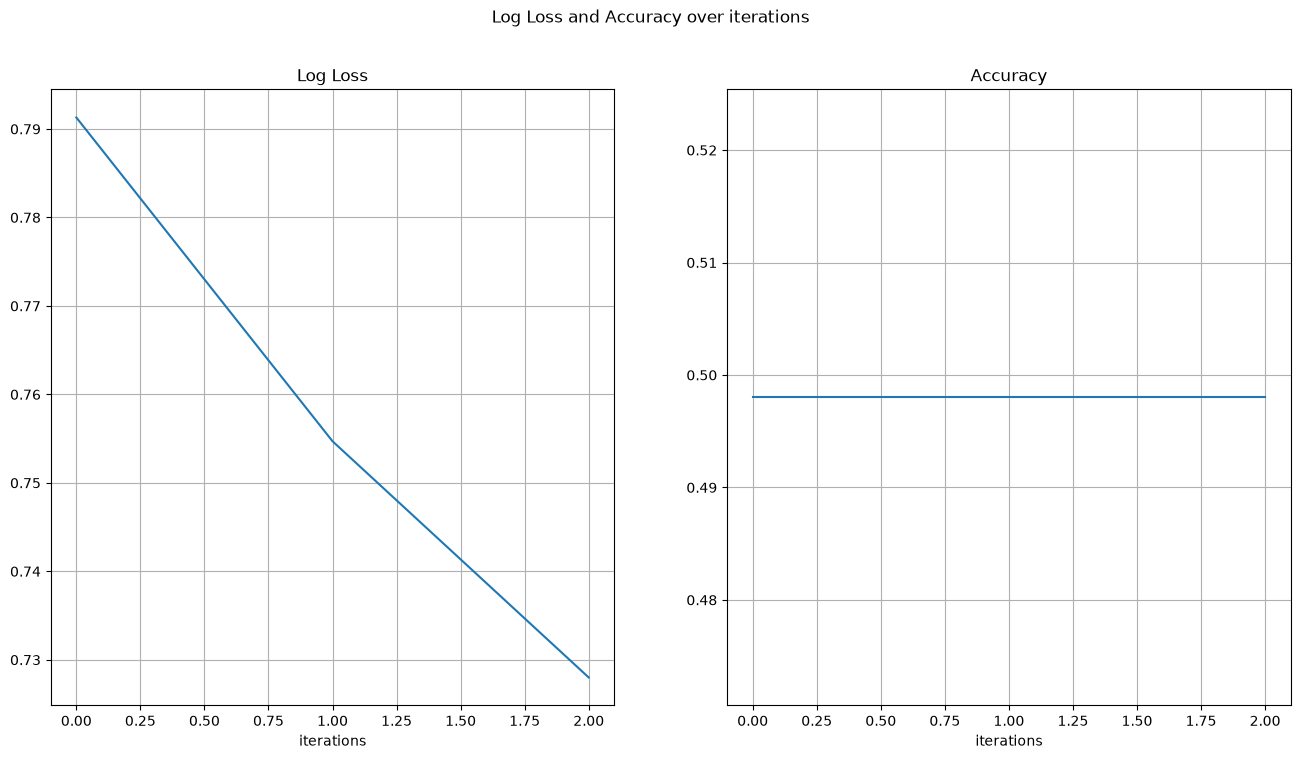

In [ ]:
# init network params
np.random.seed(1241)

W_1 = np.random.uniform(-1, 1, size=(3, 4))
W_2 = np.random.uniform(-1, 1, size=(4))
iterations = 5000
learning_rate = 0.001
x_mat = x_matrix_full

loss_vals = []
accuracies = []

for i in range(iterations):

    y_pred, (J_W_1_grad, J_W_2_grad) = forward_pass(W_1, W_2)

    W_1 = W_1 - learning_rate * J_W_1_grad
    W_2 = W_2 - learning_rate * J_W_2_grad

    current_loss = loss_fn(y, y_pred)
    loss_vals.append(current_loss)
    accuracy = np.sum((y_pred >= .5) == y) / observations
    accuracies.append(accuracy)

    if((i%200) == 0):
            print('Iteration: {} | Log Loss: {:.4f} | Accuracy: {}'.format(
                i, current_loss, accuracy
            ))
    plot_loss_accuracy(loss_vals, accuracies)

In [ ]:
pred1 = (y_pred>=.5)
pred0 = (y_pred<.5)

fig, ax = plt.subplots(figsize=(8, 8))
# true predictions
ax.plot(x_mat[pred1 & (y==1),0],x_mat[pred1 & (y==1),1], 'ro', label='True Positives')
ax.plot(x_mat[pred0 & (y==0),0],x_mat[pred0 & (y==0),1], 'bx', label='True Negatives')

# false predictions
ax.plot(x_mat[pred1 & (y==0),0],x_mat[pred1 & (y==0),1], 'yx', label='False Positives', markersize=15)
ax.plot(x_mat[pred0 & (y==1),0],x_mat[pred0 & (y==1),1], 'yo', label='False Negatives', markersize=15, alpha=.6)
ax.set(title='Actuals vs Prediction')
ax.legend(bbox_to_anchor=(1, 0.8), fancybox=True, shadow=True, fontsize='x-large');